FIRST 5 ROWS
   Size_sqft  Bedrooms  Age_years  Distance_city_km     Price
0     1200.0       2.0       15.0              10.0  220000.0
1     1500.0       3.0       10.0               8.0  280000.0
2     1800.0       3.0        8.0               6.0  340000.0
3     2000.0       4.0        5.0               5.0  400000.0
4     2200.0       4.0        4.0               4.0       NaN

MISSING VALUES
Size_sqft           1
Bedrooms            1
Age_years           2
Distance_city_km    2
Price               2
dtype: int64

MISSING VALUES AFTER CLEANING
Size_sqft           0
Bedrooms            0
Age_years           0
Distance_city_km    0
Price               0
dtype: int64

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Size_sqft         20 non-null     float64
 1   Bedrooms          20 non-null     float64
 2   Age_years    

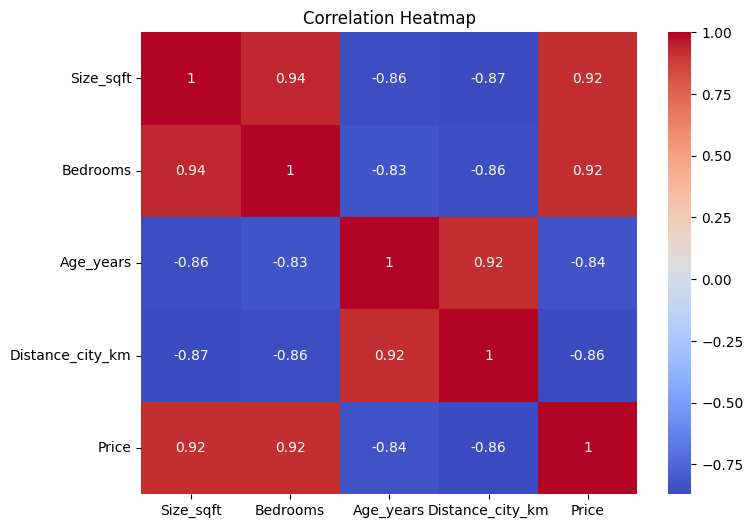

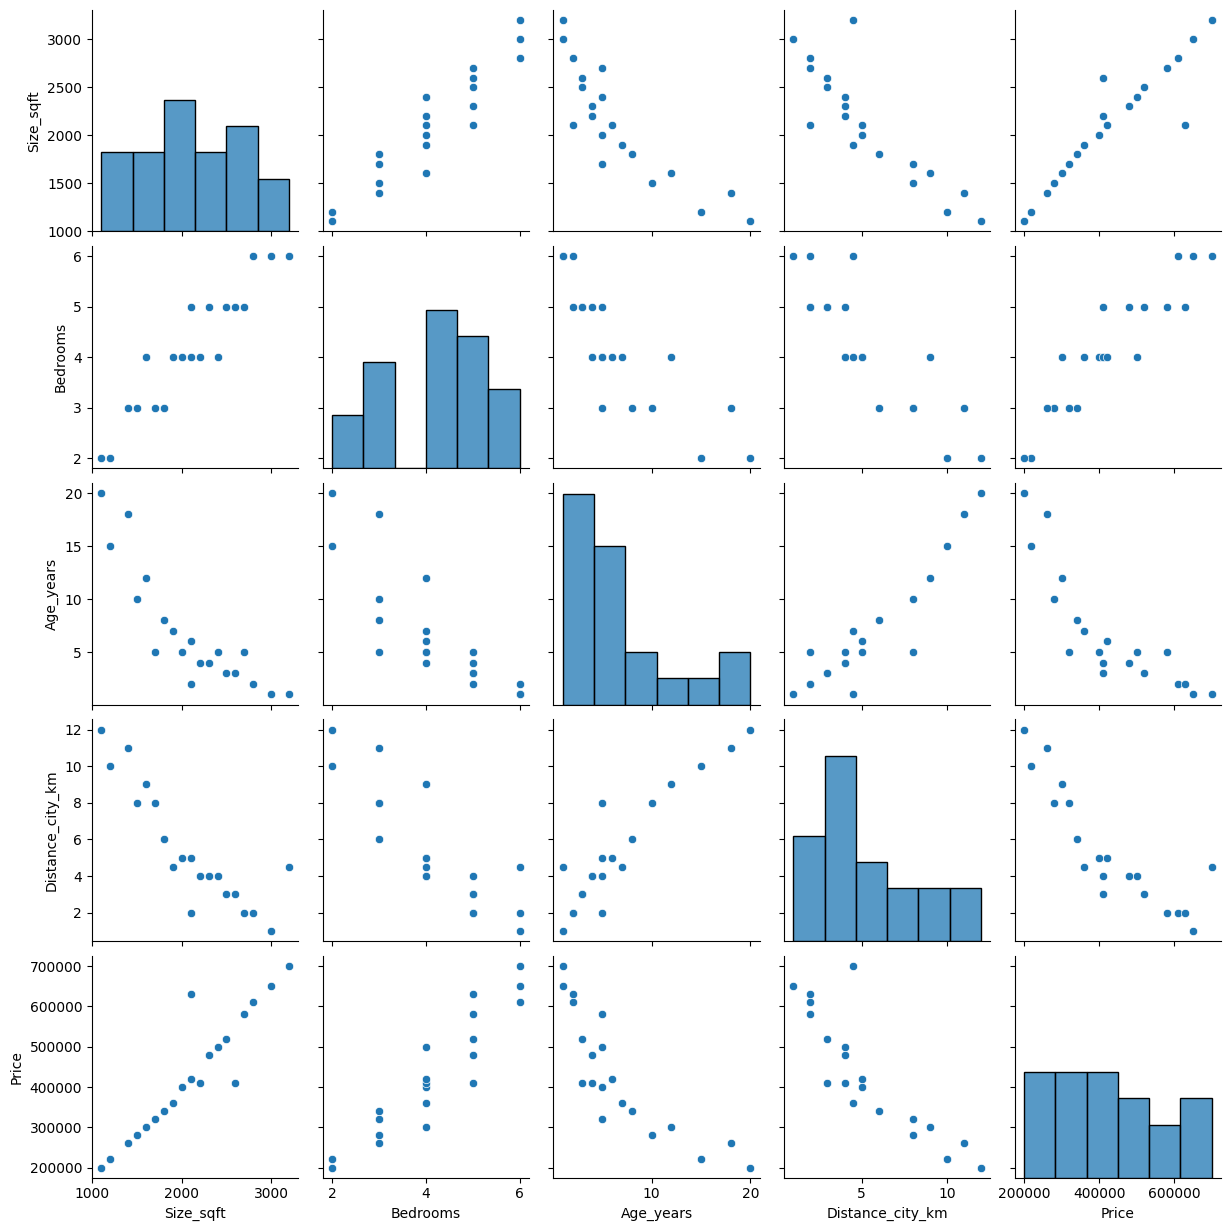

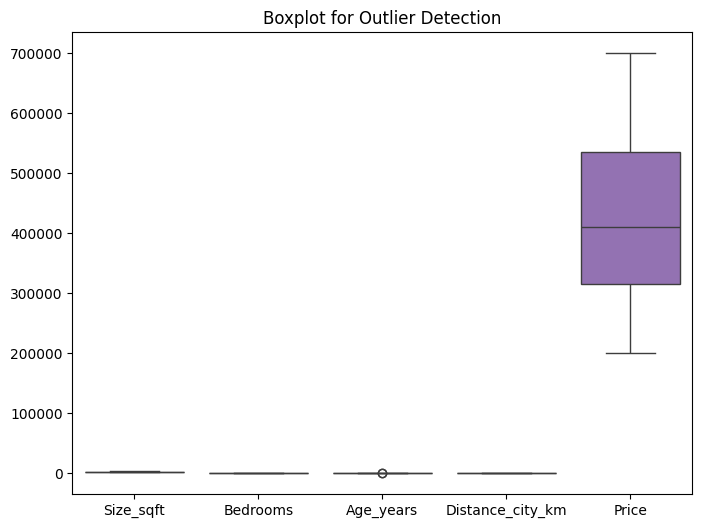


TRAINING DATA SIZE: 16
TESTING DATA SIZE: 4

MODEL TRAINED SUCCESSFULLY

MODEL COEFFICIENTS
            Feature   Coefficient
0         Size_sqft    -38.454474
1          Bedrooms  60122.987988
2         Age_years  16182.580231
3  Distance_city_km -53120.603401

MODEL INTERCEPT
416616.8139861483

PREDICTED VALUES
[202250.09051985 187561.24596718 431440.2898009  276165.04193502]

MODEL PERFORMANCE
Mean Squared Error: 22498526925.47575
R2 Score: 0.3644483919357133

ACTUAL VS PREDICTED
      Actual      Predicted
0   220000.0  202250.090520
17  320000.0  187561.245967
15  700000.0  431440.289801
1   280000.0  276165.041935


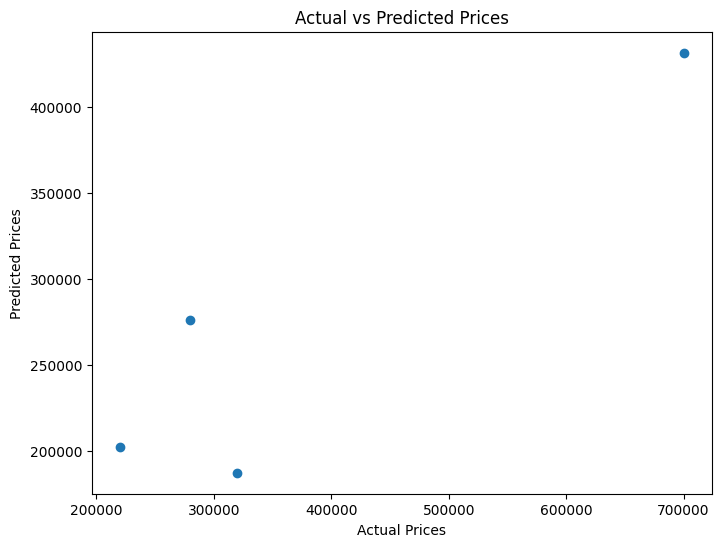

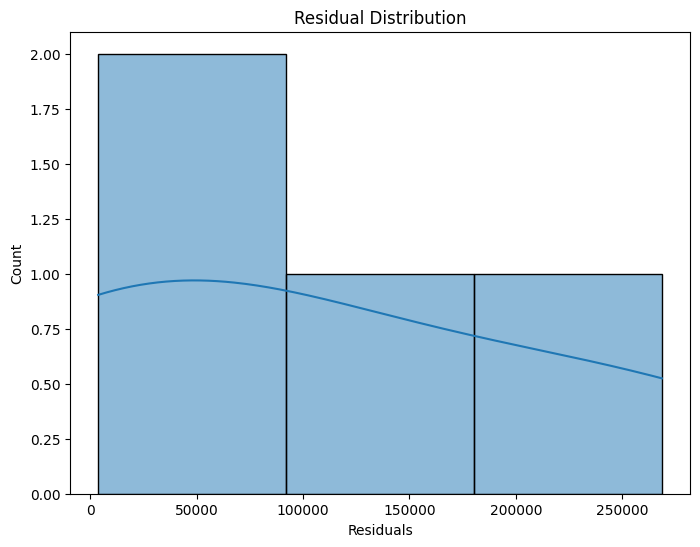

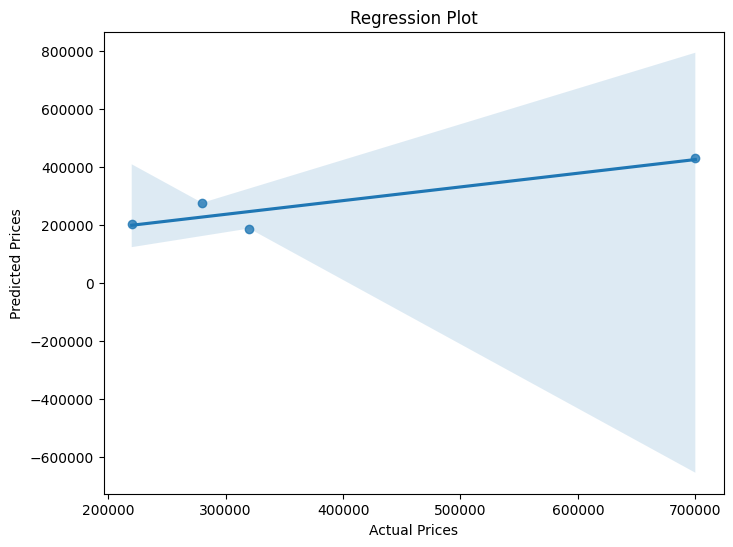


NEW HOUSE PREDICTION
Predicted Price: 482523.6717007962

CLEANED DATASET SAVED


C:\Users\manas\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
# ==========================================
# MULTIPLE LINEAR REGRESSION PROJECT
# COMPLETE END-TO-END WORKFLOW
# ==========================================

# ========= 1. IMPORT LIBRARIES =========

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ========= 2. LOAD DATASET =========

df = pd.read_csv('house_prices.csv')

print("FIRST 5 ROWS")
print(df.head())

# ========= 3. CHECK MISSING VALUES =========

print("\nMISSING VALUES")
print(df.isnull().sum())

# ========= 4. HANDLE MISSING VALUES =========

# Fill missing numerical values using median

df['Size_sqft'] = df['Size_sqft'].fillna(
    df['Size_sqft'].median()
)

df['Bedrooms'] = df['Bedrooms'].fillna(
    df['Bedrooms'].median()
)

df['Age_years'] = df['Age_years'].fillna(
    df['Age_years'].median()
)

df['Distance_city_km'] = df['Distance_city_km'].fillna(
    df['Distance_city_km'].median()
)

df['Price'] = df['Price'].fillna(
    df['Price'].median()
)

# ========= 5. VERIFY CLEAN DATA =========

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# ========= 6. BASIC DATASET INFO =========

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ========= 7. CORRELATION HEATMAP =========

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ========= 8. PAIRPLOT =========

sns.pairplot(df)

plt.show()

# ========= 9. OUTLIER DETECTION =========

plt.figure(figsize=(8,6))

sns.boxplot(data=df)

plt.title("Boxplot for Outlier Detection")
plt.show()

# ========= 10. FEATURE SELECTION =========

# Independent Variables

X = df[['Size_sqft', 'Bedrooms', 'Age_years', 'Distance_city_km']]

# Dependent Variable

y = df['Price']

# ========= 11. TRAIN-TEST SPLIT =========

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SIZE:", len(X_train))
print("TESTING DATA SIZE:", len(X_test))

# ========= 12. CREATE MODEL =========

model = LinearRegression()

# ========= 13. TRAIN MODEL =========

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")

# ========= 14. MODEL COEFFICIENTS =========

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nMODEL COEFFICIENTS")
print(coefficients)

# ========= 15. INTERCEPT =========

print("\nMODEL INTERCEPT")
print(model.intercept_)

# ========= 16. MAKE PREDICTIONS =========

y_pred = model.predict(X_test)

print("\nPREDICTED VALUES")
print(y_pred)

# ========= 17. MODEL EVALUATION =========

# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

# R2 Score

r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE")

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

# ========= 18. ACTUAL VS PREDICTED =========

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nACTUAL VS PREDICTED")
print(comparison)

# ========= 19. ACTUAL VS PREDICTED PLOT =========

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

# ========= 20. RESIDUAL ANALYSIS =========

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

# ========= 21. REGRESSION PLOT =========

plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Regression Plot")

plt.show()

# ========= 22. PREDICT NEW HOUSE PRICE =========

# Format:
# [Size_sqft, Bedrooms, Age_years, Distance_city_km]

new_house = [[2500, 4, 5, 3]]

predicted_price = model.predict(new_house)

print("\nNEW HOUSE PREDICTION")
print("Predicted Price:", predicted_price[0])

# ========= 23. SAVE CLEANED DATASET =========

df.to_csv('cleaned_house_prices.csv', index=False)

print("\nCLEANED DATASET SAVED")

# ==========================================
# END OF PROJECT
# ==========================================